# Required parameters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# Exercise 1

In [2]:
widget_sales = pd.read_csv("data/widget_sales.csv")

In [3]:
widget_sales.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


In [5]:
adfuller(widget_sales.iloc[:, 0])

(np.float64(-1.5121662069359034),
 np.float64(0.5274845352272611),
 3,
 496,
 {'1%': np.float64(-3.4436029548776395),
  '5%': np.float64(-2.867384756137026),
  '10%': np.float64(-2.5698830308597813)},
 np.float64(1354.8017397952053))

The time series is already stationary, then we shouldn't use the differenciation.

## Testing GOF for ARIMA(0, 1, 2)

In [13]:
model_fit = SARIMAX(widget_sales.iloc[:, 0].values, 
                   order=(0, 1, 2), simple_differencing=False).fit(disp=False)

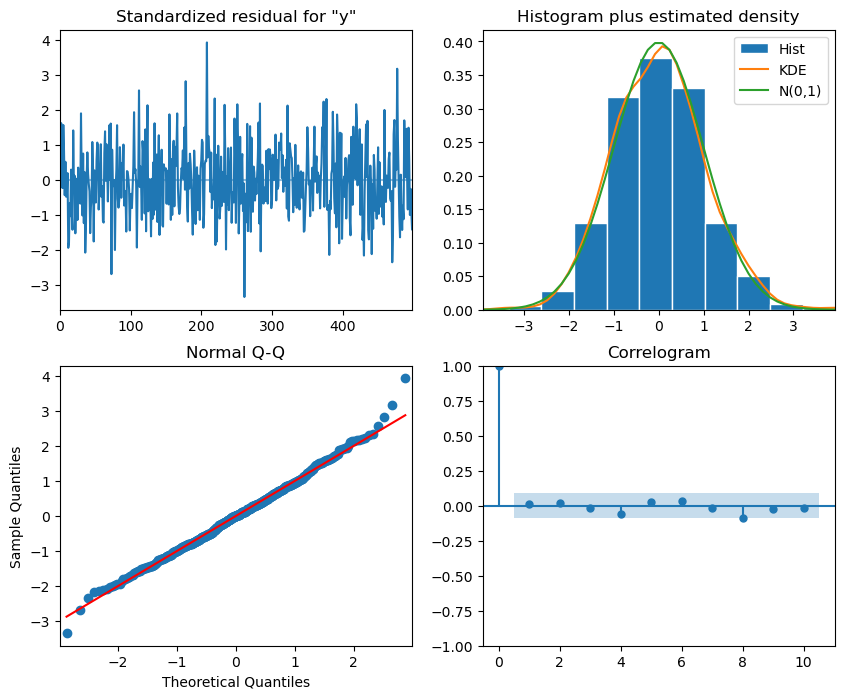

In [15]:
model_fit.plot_diagnostics(figsize=(10, 8));

## Ljung-box test

In [19]:
df_ljungbox = acorr_ljungbox(model_fit.resid, lags=15)

In [20]:
df_ljungbox.info()

<class 'pandas.DataFrame'>
Index: 15 entries, 1 to 15
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lb_stat    15 non-null     float64
 1   lb_pvalue  15 non-null     float64
dtypes: float64(2)
memory usage: 360.0 bytes


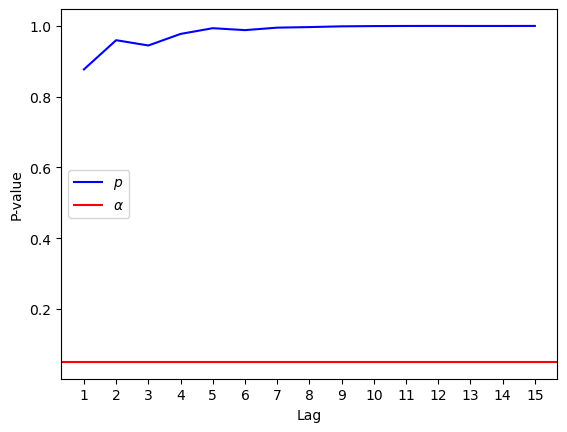

In [27]:
fig, ax = plt.subplots()
ax.plot(df_ljungbox['lb_pvalue'], 'b-', label='$p$')
ax.axhline(0.05, color='red', label='$\\alpha$') 
ax.set_xticks(np.arange(1, 16, 1))
ax.set_xlabel('Lag')
ax.set_ylabel('P-value')
ax.legend(loc='center left')
plt.show()

# Exercise 2

In [6]:
foot_traffic = pd.read_csv('data/foot_traffic.csv')

In [7]:
foot_traffic.head()

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


In [8]:
adfuller(foot_traffic.iloc[:, 0])

(np.float64(-1.1758885999240754),
 np.float64(0.6838808917896186),
 3,
 996,
 {'1%': np.float64(-3.4369325637409154),
  '5%': np.float64(-2.8644462162311934),
  '10%': np.float64(-2.568317409920808)},
 np.float64(2740.300875453594))

The time series is already stationary, then we shouldn't use the differenciation.

## Testing GOF for ARIMA(3, 1, 0)

In [28]:
model_fit = SARIMAX(foot_traffic.iloc[:, 0].values, 
                   order=(3, 1, 0), simple_differencing=False).fit(disp=False)

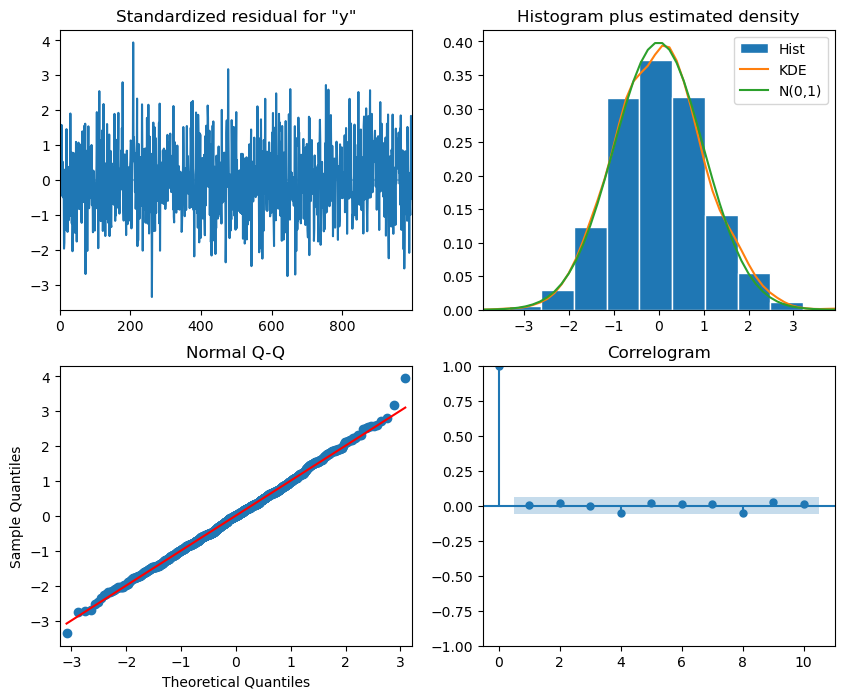

In [30]:
model_fit.plot_diagnostics(figsize=(10, 8));

## Ljung-box plot

In [32]:
df_ljungbox = acorr_ljungbox(model_fit.resid, lags=15)

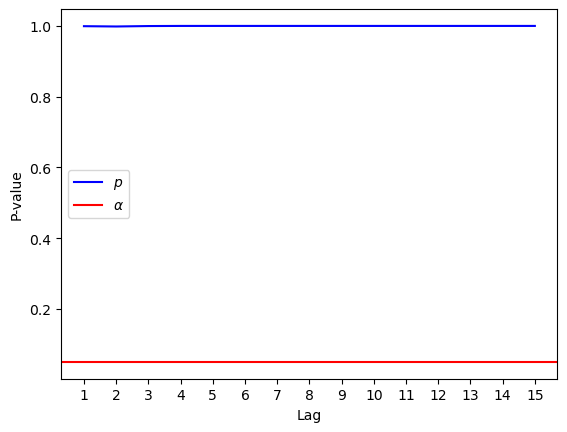

In [33]:
fig, ax = plt.subplots()
ax.plot(df_ljungbox['lb_pvalue'], 'b-', label='$p$')
ax.axhline(0.05, color='red', label='$\\alpha$') 
ax.set_xticks(np.arange(1, 16, 1))
ax.set_xlabel('Lag')
ax.set_ylabel('P-value')
ax.legend(loc='center left')
plt.show()

# Exercise 3

In [9]:
df_bandwidth = pd.read_csv('data/bandwidth.csv')

In [10]:
df_bandwidth.head()

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816


In [11]:
adfuller(df_bandwidth.iloc[:, 0])

(np.float64(-0.8714653199452549),
 np.float64(0.7972240255014611),
 6,
 9993,
 {'1%': np.float64(-3.431004556246501),
  '5%': np.float64(-2.8618292749021865),
  '10%': np.float64(-2.5669239758928017)},
 np.float64(28347.577478302363))

## Testing GOF for ARIMA(2, 1, 2)

In [34]:
model_fit = SARIMAX(df_bandwidth.iloc[:, 0].values, 
                   order=(2, 1, 2), simple_differencing=False).fit(disp=False)

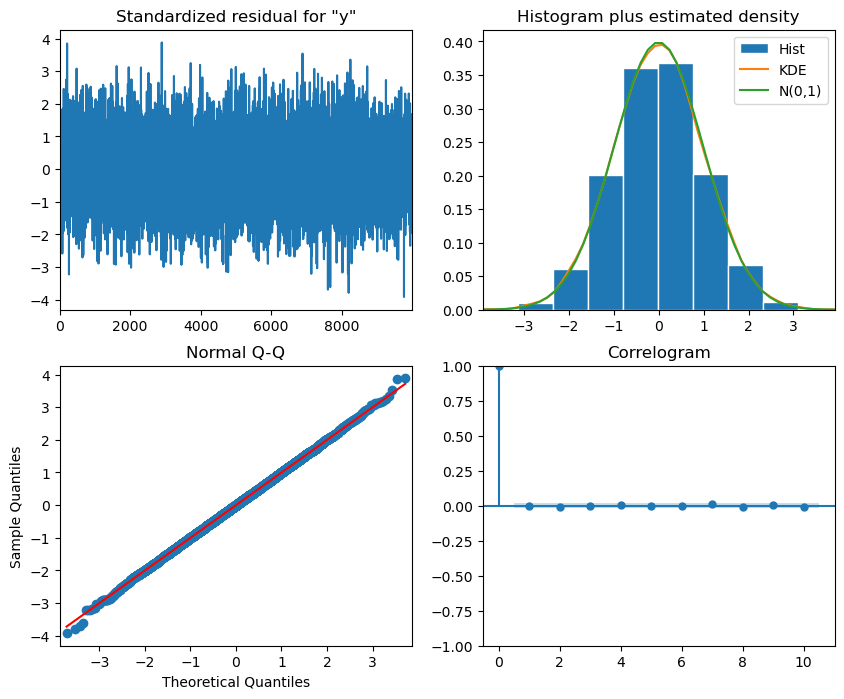

In [36]:
model_fit.plot_diagnostics(figsize=(10, 8));

## Ljung-box plot

In [37]:
df_ljungbox = acorr_ljungbox(model_fit.resid, lags=15)

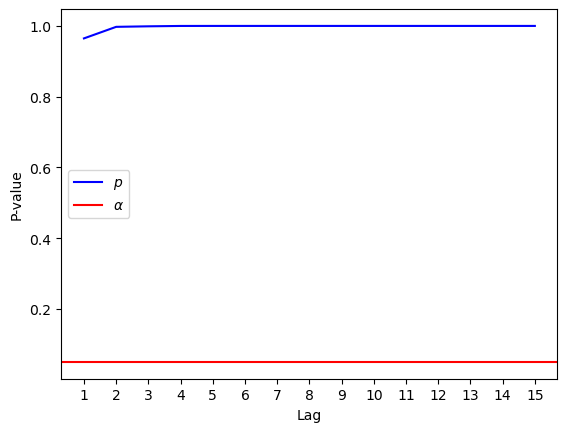

In [38]:
fig, ax = plt.subplots()
ax.plot(df_ljungbox['lb_pvalue'], 'b-', label='$p$')
ax.axhline(0.05, color='red', label='$\\alpha$') 
ax.set_xticks(np.arange(1, 16, 1))
ax.set_xlabel('Lag')
ax.set_ylabel('P-value')
ax.legend(loc='center left')
plt.show()